In [105]:
#Import Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')

In [106]:
#Read dataset
df=pd.read_csv("ncr_ride_bookings.csv")
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

### Data Type Conversion and Missing Value Handling for `ncr_ride_bookings.csv`

In [108]:
# Reload the dataset to ensure we are working with 'ncr_ride_bookings.csv'
df = pd.read_csv("ncr_ride_bookings.csv")

# Convert 'Date' and 'Time' to datetime objects and combine them
df['Booking_Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Drop original 'Date' and 'Time' columns
df.drop(columns=['Date', 'Time'], inplace=True)

# For count-related columns with NaNs, fill NaNs with 0 and convert to integer
count_columns = ['Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides']
for col in count_columns:
    df[col] = df[col].fillna(0).astype(int)

# Display updated info to check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Booking ID                         150000 non-null  object        
 1   Booking Status                     150000 non-null  object        
 2   Customer ID                        150000 non-null  object        
 3   Vehicle Type                       150000 non-null  object        
 4   Pickup Location                    150000 non-null  object        
 5   Drop Location                      150000 non-null  object        
 6   Avg VTAT                           139500 non-null  float64       
 7   Avg CTAT                           102000 non-null  float64       
 8   Cancelled Rides by Customer        150000 non-null  int64         
 9   Reason for cancelling by Customer  10500 non-null   object        
 10  Cancelled Rides by D

In [109]:
# check Missing value
df.isnull().sum()

,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000
Cancelled Rides by Customer,0
Reason for cancelling by Customer,139500


In [110]:
#Data cleaning:
df['Payment Method'].fillna(df['Payment Method'].mode()[0], inplace=True)
df['Avg VTAT'].fillna(df['Avg VTAT'].median(), inplace=True)
df['Avg CTAT'].fillna(df['Avg CTAT'].median(),inplace=True)
df['Cancelled Rides by Customer'].fillna(df['Cancelled Rides by Customer'].median(), inplace=True)
df['Reason for cancelling by Customer'].fillna(df['Reason for cancelling by Customer'].mode()[0], inplace=True)
df['Driver Cancellation Reason'].fillna(df['Driver Cancellation Reason'].mode()[0], inplace=True)
df['Cancelled Rides by Driver'].fillna(df['Cancelled Rides by Driver'].mode()[0], inplace=True)
df['Incomplete Rides'].fillna(df['Incomplete Rides'].mode()[0], inplace=True)
df['Incomplete Rides Reason'].fillna(df['Incomplete Rides Reason'].mode()[0], inplace=True)
df['Booking Value'].fillna(df['Booking Value'].median(),inplace=True)
df['Ride Distance'].fillna(df['Ride Distance'].median(), inplace=True)
df['Driver Ratings'].fillna(df['Driver Ratings'].median(), inplace=True)
df['Customer Rating'].fillna(df['Customer Rating'].median(), inplace=True)


In [111]:
#Ensure that there are no missing values.
df.isnull().sum()

,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,0
Avg CTAT,0
Cancelled Rides by Customer,0
Reason for cancelling by Customer,0


In [112]:
#Clean up column 'max_power' and convert it to numeric data type
columns_to_encode = ['Payment Method', 'Vehicle Type', 'Booking Status']

df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)


**Datetime Feature Engineering**

In [113]:
if 'Date' in df.columns and 'Time' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Time'] = pd.to_datetime(df['Time'])

    df['Day_of_Week'] = df['Date'].dt.dayofweek
    df['Month'] = df['Date'].dt.month
    df['Hour'] = df['Time'].dt.hour
    df['Is_Weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

    df.drop(['Date', 'Time'], axis=1, inplace=True)
    print("✅ تم استخراج البيانات وحذف الأعمدة الأصلية بنجاح!")
else:
    print("⚠️ الأعمدة محذوفة مسبقاً، البيانات الجديدة (Hour, Day_of_Week) جاهزة للاستخدام.")

⚠️ الأعمدة محذوفة مسبقاً، البيانات الجديدة (Hour, Day_of_Week) جاهزة للاستخدام.


In [114]:
df.drop(['Customer ID','Booking ID'],axis=1,inplace=True)
df.head()

,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,...,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,Booking Status_Cancelled by Driver,Booking Status_Completed,Booking Status_Incomplete,Booking Status_No Driver Found
0,Palam Vihar,Jhilmil,8.3,28.8,0,Wrong Address,0,Customer related issue,0,Customer Demand,...,False,False,False,False,False,True,False,False,False,True
1,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,Wrong Address,0,Customer related issue,1,Vehicle Breakdown,...,False,False,True,False,False,False,False,False,True,False
2,Khandsa,Malviya Nagar,13.4,25.8,0,Wrong Address,0,Customer related issue,0,Customer Demand,...,False,False,False,False,False,False,False,True,False,False
3,Central Secretariat,Inderlok,13.1,28.5,0,Wrong Address,0,Customer related issue,0,Customer Demand,...,False,False,False,True,False,False,False,True,False,False
4,Ghitorni Village,Khan Market,5.3,19.6,0,Wrong Address,0,Customer related issue,0,Customer Demand,...,True,False,False,False,False,False,False,True,False,False


**Frequency / Count Encoding**

In [115]:
pickup_counts = df['Pickup Location'].value_counts()
drop_counts = df['Drop Location'].value_counts()
df['Pickup Location'] = df['Pickup Location'].map(pickup_counts)
df['Drop Location'] = df['Drop Location'].map(drop_counts)

In [116]:
# Check Duplication
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 29 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   Pickup Location                     150000 non-null  int64         
 1   Drop Location                       150000 non-null  int64         
 2   Avg VTAT                            150000 non-null  float64       
 3   Avg CTAT                            150000 non-null  float64       
 4   Cancelled Rides by Customer         150000 non-null  int64         
 5   Reason for cancelling by Customer   150000 non-null  object        
 6   Cancelled Rides by Driver           150000 non-null  int64         
 7   Driver Cancellation Reason          150000 non-null  object        
 8   Incomplete Rides                    150000 non-null  int64         
 9   Incomplete Rides Reason             150000 non-null  object        
 10  Booking 

In [117]:
df.drop(['Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason'], axis=1, inplace=True)
# لانو رح يسببو بي (Data Leakage)   يعني متل غششتو لل الموديل

In [118]:
#Display descriptive statistics for
df.describe()

,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Booking_Datetime
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000
mean,853.327360,853.242067,8.445407,29.037753,0.070000,0.180000,0.060000,478.121220,24.343568,4.257215,4.440842,2024-07-01 07:14:41.251033344
min,790.000000,774.000000,2.000000,10.000000,0.000000,0.000000,0.000000,50.000000,1.000000,3.000000,3.000000,2024-01-01 00:19:34
25%,830.000000,836.000000,5.600000,25.000000,0.000000,0.000000,0.000000,319.750000,17.360000,4.200000,4.300000,2024-03-31 22:55:36.249999872
50%,850.000000,851.000000,8.300000,28.800000,0.000000,0.000000,0.000000,414.000000,23.720000,4.300000,4.500000,2024-07-01 09:24:52.500000
75%,872.000000,871.000000,11.000000,32.900000,0.000000,0.000000,0.000000,521.000000,30.650000,4.300000,4.600000,2024-09-30 13:46:07.249999872
max,949.000000,936.000000,20.000000,45.000000,1.000000,1.000000,1.000000,4277.000000,50.000000,5.000000,5.000000,2024-12-30 23:36:11
std,30.264786,28.768517,3.639311,7.343053,0.255148,0.384189,0.237488,329.339976,11.554362,0.345619,0.347835,NaN


In [119]:
# Check Duplication
df.duplicated().sum()

np.int64(0)

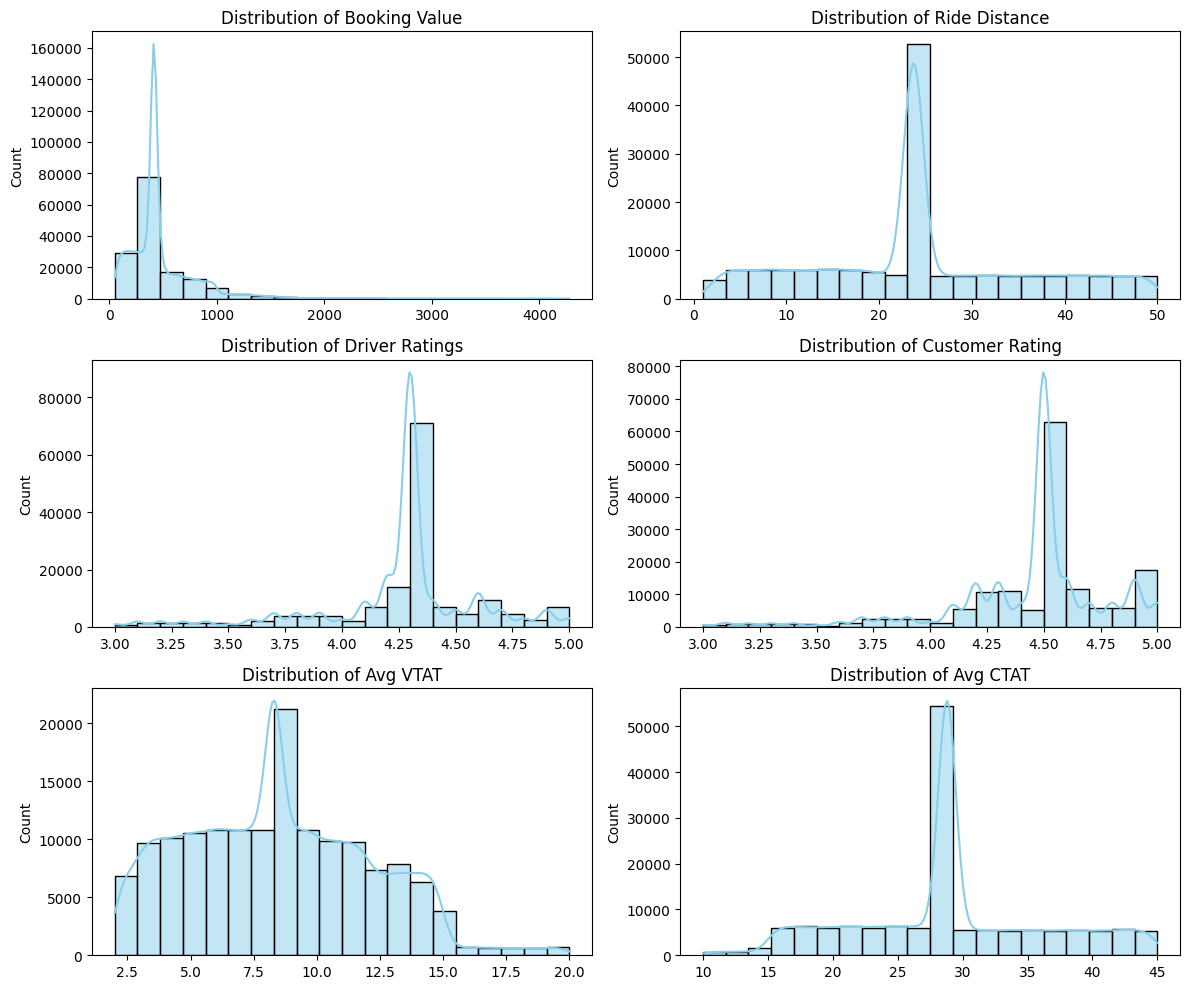

In [120]:

numerical_features = ['Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Avg VTAT', 'Avg CTAT']

plt.figure(figsize=(12, 10))

for i, feature in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1) # تقسيم اللوحة إلى 3 صفوف وعمودين
    sns.histplot(data=df, x=feature, bins=20, kde=True, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=12)
    plt.xlabel('')
plt.tight_layout()
plt.show()

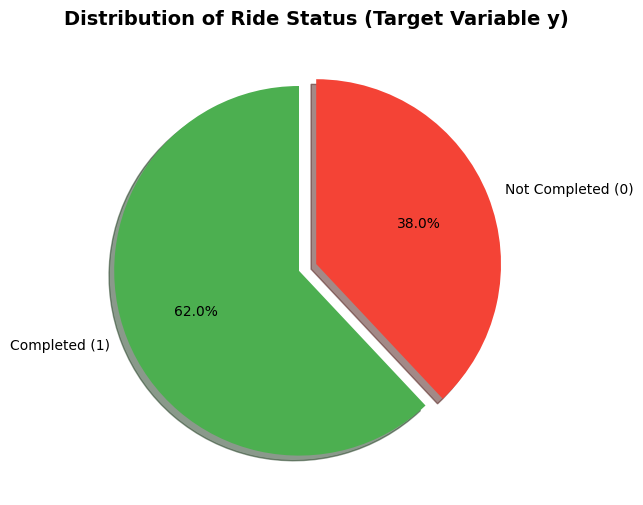

In [121]:

# حساب عدد الرحلات المكتملة وغير المكتملة
status_counts = df['Booking Status_Completed'].value_counts()

# إعداد حجم اللوحة
plt.figure(figsize=(8, 6))

# رسم المخطط الدائري
# استخدمنا الألوان: الأخضر للرحلات المكتملة، والأحمر للملغاة
plt.pie(status_counts,
        labels=['Completed (1)', 'Not Completed (0)'],
        autopct='%1.1f%%', # لإظهار النسبة المئوية
        startangle=90,
        colors=['#4CAF50', '#F44336'],
        explode=(0.1, 0), # لفصل الجزء الأول قليلاً وإبرازه
        shadow=True)

# إضافة عنوان للمخطط
plt.title('Distribution of Ride Status (Target Variable y)', fontsize=14, fontweight='bold')

# عرض الرسم
plt.show()

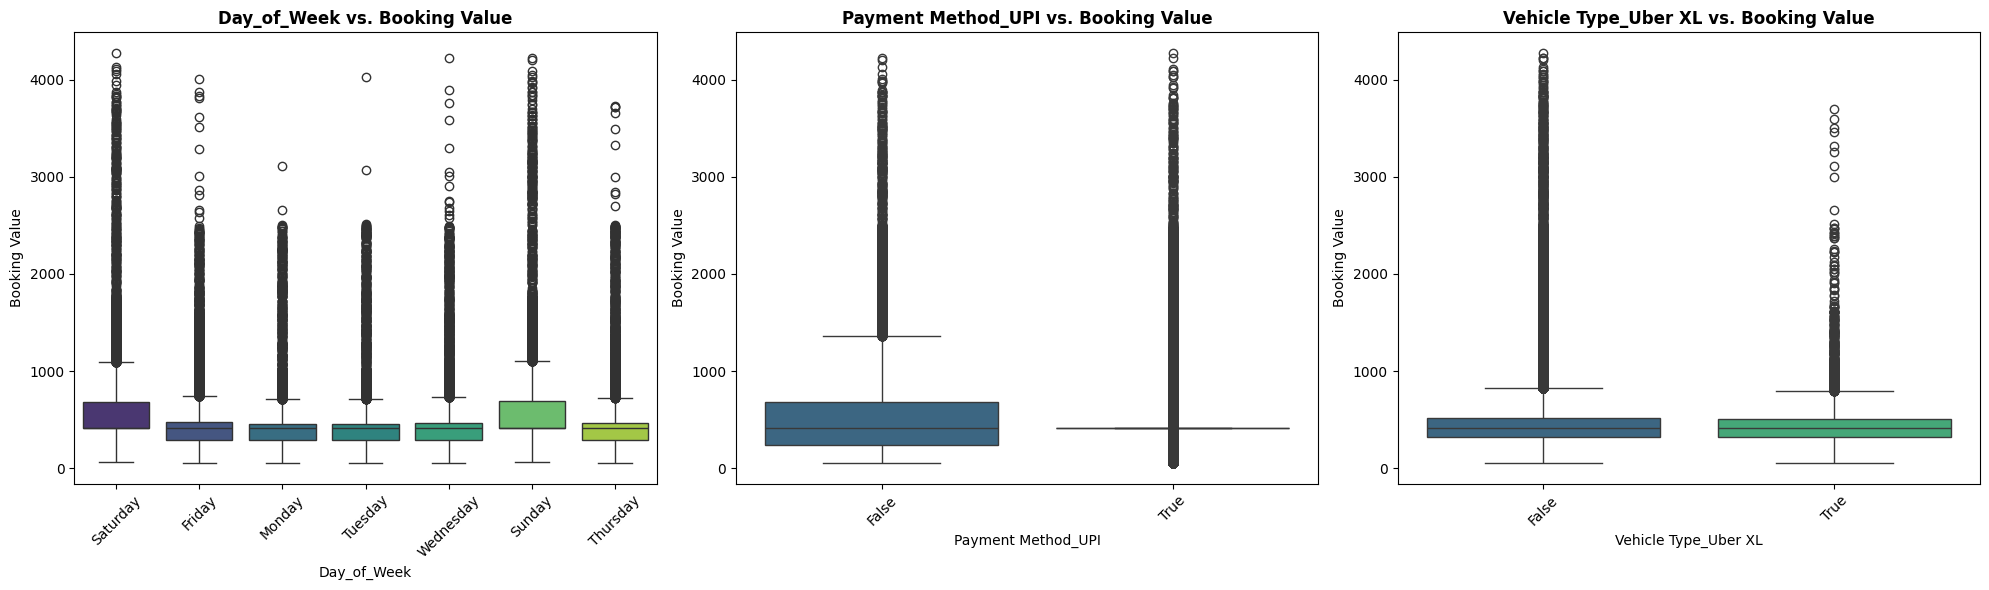

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['Booking_Datetime'] = pd.to_datetime(df['Booking_Datetime'])

df['Day_of_Week'] = df['Booking_Datetime'].dt.day_name()
df['Hour'] = df['Booking_Datetime'].dt.hour
features_to_plot = ['Day_of_Week', 'Payment Method_UPI', 'Vehicle Type_Uber XL']

plt.figure(figsize=(20, 6))

for index, feature in enumerate(features_to_plot):
    plt.subplot(1, 3, index + 1)
    sns.boxplot(data=df, x=feature, y='Booking Value', palette='viridis')

    plt.title(f'{feature} vs. Booking Value', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [127]:
# 1. تحديد الهدف (النتيجة)
y = df['Booking Status_Completed']

# 2. حذف أعمدة النتيجة + حذف عمود التاريخ والوقت الأصلي (الجاسوس الأخير)
# انتبه: أضفت 'Booking_Datetime' للقائمة لأنه هو سبب المشكلة
columns_to_drop = [
    'Booking Status_Completed',
    'Booking Status_Cancelled by Driver',
    'Booking Status_Incomplete',
    'Booking Status_No Driver Found',
    'Booking_Datetime' # <--- هذا هو المتهم الذي يسبب الخطأ!
]

# التأكد من حذف أي أعمدة نصية أخرى متبقية (مثل Pickup/Drop Location إذا لم تحولها)
X = df.drop(columns_to_drop, axis=1)

# نصيحة: لنبقي فقط الأعمدة الرقمية لضمان عمل الموديل
X = X.select_dtypes(include=['number'])

# 3. تقسيم البيانات
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. تدريب النموذج
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print(f"حجم بيانات التدريب النظيفة: {X_train.shape}")
model = LogisticRegression(max_iter=1000, random_state=42)

print("جاري تدريب النموذج على البيانات الرقمية فقط... ⏳")
model.fit(X_train, y_train)

# 5. النتائج
print("انتهى التدريب بنجاح! 🎉")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("-" * 40)
print(f"🎯 دقة النموذج (Accuracy): {accuracy * 100:.2f} %")

حجم بيانات التدريب النظيفة: (120000, 12)
جاري تدريب النموذج على البيانات الرقمية فقط... ⏳
انتهى التدريب بنجاح! 🎉
----------------------------------------
🎯 دقة النموذج (Accuracy): 93.01 %


رح جرب اعمل train
عن طريق ال random forest
وشوف الفرق



In [137]:
# 1. تحديد الهدف (y)
y = df['Booking Status_Completed']

# 2. تحديد الأعمدة التي تسبب الغش (Data Leakage)
leakage_columns = [
    'Booking Status_Completed',
    'Booking Status_Cancelled by Driver',
    'Booking Status_Incomplete',
    'Booking Status_No Driver Found',
    'Cancelled Rides by Customer',
    'Cancelled Rides by Driver',
    'Incomplete Rides'
]

# 3. حذف أعمدة الغش
X_temp = df.drop(leakage_columns, axis=1)

# 4. الحــــــــل السحري: إبقاء الأعمدة الرقمية فقط وحذف التواريخ والنصوص
# هذا السطر سيحذف 'Booking_Datetime' وأي نص آخر يسبب TypeError
X_clean = X_temp.select_dtypes(include=['number'])

# 5. تقسيم البيانات
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

# 6. تدريب الغابات العشوائية (الوحش)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print(f"جاري التدريب على {X_train.shape[1]} عموداً رقمياً نظيفاً... ⏳")
rf_model_real = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_real.fit(X_train, y_train)

# 7. النتائج
rf_y_pred_real = rf_model_real.predict(X_test)
rf_accuracy_real = accuracy_score(y_test, rf_y_pred_real)

print("-" * 40)
print(f"🎯 الدقة الحقيقية للغابات العشوائية: {rf_accuracy_real * 100:.2f} %")
print("\n📊 التقرير المفصل:")
print(classification_report(y_test, rf_y_pred_real))

جاري التدريب على 9 عموداً رقمياً نظيفاً... ⏳
----------------------------------------
🎯 الدقة الحقيقية للغابات العشوائية: 99.96 %

📊 التقرير المفصل:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     11358
        True       1.00      1.00      1.00     18642

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



In [138]:
spies_to_drop = [
    'Customer Rating',
    'Driver Ratings',
    'Avg CTAT',
    'Avg VTAT' ]

X_super_clean = X_clean.drop(spies_to_drop, axis=1)

X_train_final, X_test_final, y_train, y_test = train_test_split(X_super_clean, y, test_size=0.2, random_state=42)

rf_model_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_final.fit(X_train_final, y_train)

rf_y_pred_final = rf_model_final.predict(X_test_final)

from sklearn.metrics import accuracy_score, classification_report
final_accuracy = accuracy_score(y_test, rf_y_pred_final)

print("-" * 40)
print(f"🎯 الدقة النهائية الحقيقية (Real Accuracy): {final_accuracy * 100:.2f} %")
print(classification_report(y_test, rf_y_pred_final))
print("بنلاحظ انو كيف فرق بعد ما اكتشفت التسريب البيانات وحذفتو")

----------------------------------------
🎯 الدقة النهائية الحقيقية (Real Accuracy): 94.34 %
              precision    recall  f1-score   support

       False       1.00      0.85      0.92     11358
        True       0.92      1.00      0.96     18642

    accuracy                           0.94     30000
   macro avg       0.96      0.93      0.94     30000
weighted avg       0.95      0.94      0.94     30000

بنلاحظ انو كيف فرق بعد ما اكتشفت التسريب البيانات وحذفتو


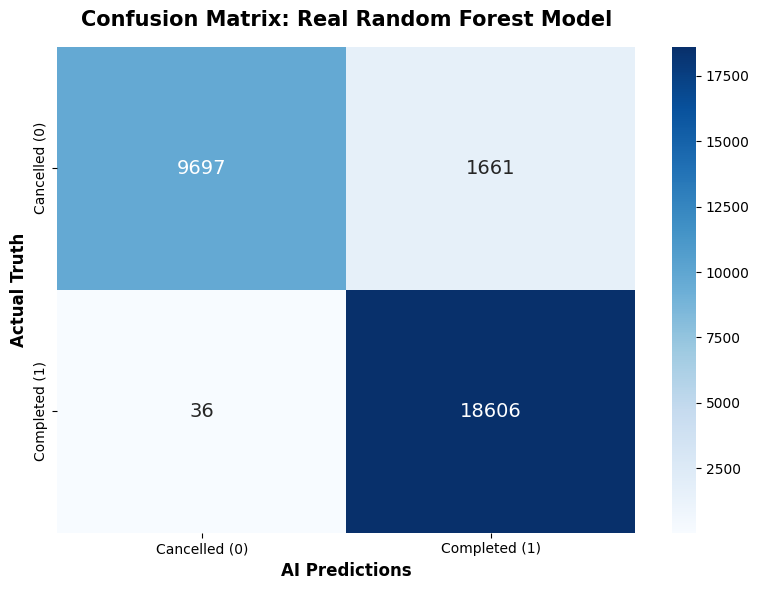

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculate confusion matrix from real predictions
cm = confusion_matrix(y_test, rf_y_pred_final)

# 2. Setup the plot
plt.figure(figsize=(8, 6))

# 3. Draw the Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cancelled (0)', 'Completed (1)'],
            yticklabels=['Cancelled (0)', 'Completed (1)'],
            annot_kws={"size": 14})

# 4. Add English Titles and Labels
plt.title('Confusion Matrix: Real Random Forest Model', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('AI Predictions', fontsize=12, fontweight='bold')
plt.ylabel('Actual Truth', fontsize=12, fontweight='bold')

# 5. Show the plot
plt.tight_layout()
plt.show()